In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import roc_auc_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv("processed_credit_card.csv")
#print first 5 rows 
print(df.head())

#print last 5 rows 
print("\n", df.tail())


   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1   PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month
0      20000    2          2         1   24      2      2     -1     -1     -2     -2       3913       3102        689          0          0          0  0.000000   6.536692  0.000000  0.000000  0.000000  0.000000                           1
1     120000    2          2         2   26     -1      2      0      0      0      2       2682       1725       2682       3272       3455       3261  0.000000   6.908755  6.908755  6.908755  0.000000  7.601402                           1
2      90000    2          2         2   34      0      0      0      0      0      0      29239      14027      13559      14331      14948      15549  7.325808   7.313887  6.908755  6.908755  6.908755  8.517393                           0
3      50000    2          2        

In [4]:
#splitting 
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

#feature scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed Successfully!")

(24000, 23)
(6000, 23)
(24000,)
(6000,)
Feature Scaling Completed Successfully!


In [5]:
# Convert to dataframe
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

print(X_train_scaled.head())

       LIMIT_BAL      SEX  EDUCATION  MARRIAGE       AGE     PAY_0     PAY_2     PAY_3     PAY_4     PAY_5     PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6
22788  -0.056866  0.80844   0.211520  0.846502 -0.264558  1.793311  1.780193  2.652046  1.911811  0.240260  0.256087   1.505547   1.745089   1.778869   1.891679   2.020839   2.096346  0.918339 -2.001046 -1.873268  0.776365  0.982673  0.791001
29006  -0.134081  0.80844  -1.131465  0.846502 -0.155804  0.902944 -0.722324 -0.697642 -1.530826 -1.537252 -1.489963  -0.695165  -0.691138  -0.685090  -0.673845  -0.662488  -0.652126 -0.816245 -2.001046 -1.873268 -1.785923 -1.748147 -1.673047
16950  -1.215090 -1.23695   0.211520 -1.071916  1.584260  0.902944  1.780193  0.139780  0.190493  0.240260  0.256087  -0.556800  -0.576836  -0.561615  -0.547887  -0.526789  -0.510492 -1.707251  0.179965  0.224168 -0.114133 -0.088451  0.280039
22280   0.406423  0.80844  -

Accuracy Percentage : 80.62%
Precision : 0.66
Recall    : 0.25
F1-Score  : 0.37
confusion matrix for logistic regression
 [[4501  172]
 [ 991  336]]


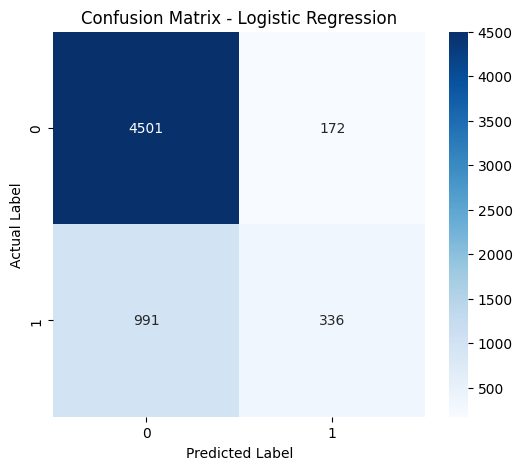

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.66      0.25      0.37      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.61      0.63      6000
weighted avg       0.78      0.81      0.77      6000

ROC-AUC Score : 0.7345621425718235


In [6]:
#logistic regression 
model_lr= LogisticRegression(random_state=42)
model_lr.fit(X_train_scaled,y_train)

y_pred_lr=model_lr.predict(X_test_scaled)

accuracy_lr=accuracy_score(y_test,y_pred_lr)
print(f"Accuracy Percentage : {accuracy_lr*100:.2f}%")

precision_lr=precision_score(y_test,y_pred_lr)

recall_lr=recall_score(y_test,y_pred_lr)

f1_lr=f1_score(y_test,y_pred_lr)

print(f"Precision : {precision_lr:.2f}")
print(f"Recall    : {recall_lr:.2f}")
print(f"F1-Score  : {f1_lr:.2f}")

lr_matrix=confusion_matrix(y_test,y_pred_lr)
print("confusion matrix for logistic regression\n",lr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(lr_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_lr))

y_prob_lr = model_lr.predict_proba( X_test_scaled)[:,1]
roc_lr= roc_auc_score(y_test,y_prob_lr)
print("ROC-AUC Score :", roc_lr)

In [7]:
'''
Observation:-
- Accuracy:80.62%
- Precision:0.66
- Recall:0.25
- F1-Score:0.37
- ROC-AUC:0.7345
'''

'\nObservation:-\n- Accuracy:80.62%\n- Precision:0.66\n- Recall:0.25\n- F1-Score:0.37\n- ROC-AUC:0.7345\n'

Accuracy Percentage : 71.95%
Precision : 0.38
Recall    : 0.41
F1-Score  : 0.39
confusion matrix for Decision tree
 [[3772  901]
 [ 782  545]]


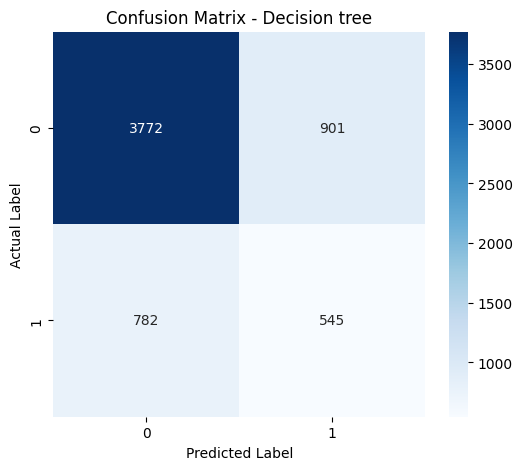

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.41      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.61      6000
weighted avg       0.73      0.72      0.72      6000

ROC-AUC Score : 0.610403186804344


In [8]:
#decision tree
model_dt= DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train,y_train)

y_pred_dt=model_dt.predict(X_test)

accuracy_dt=accuracy_score(y_test,y_pred_dt)
print(f"Accuracy Percentage : {accuracy_dt*100:.2f}%")

precision_dt=precision_score(y_test,y_pred_dt)

recall_dt=recall_score(y_test,y_pred_dt)

f1_dt=f1_score(y_test,y_pred_dt)

print(f"Precision : {precision_dt:.2f}")
print(f"Recall    : {recall_dt:.2f}")
print(f"F1-Score  : {f1_dt:.2f}")

dt_matrix=confusion_matrix(y_test,y_pred_dt)
print("confusion matrix for Decision tree\n",dt_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(dt_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - Decision tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_dt))

y_prob_dt= model_dt.predict_proba( X_test)[:,1]
roc_dt= roc_auc_score(y_test,y_prob_dt)
print("ROC-AUC Score :", roc_dt)

In [9]:
'''
Observation:-
- Accuracy: 71.95%
- Precision: 0.38
- Recall: 0.41
- F1-Score:0.39
- ROC-AUC: 0.6104
'''

'\nObservation:-\n- Accuracy: 71.95%\n- Precision: 0.38\n- Recall: 0.41\n- F1-Score:0.39\n- ROC-AUC: 0.6104\n'

Accuracy Percentage : 81.43%
Precision : 0.64
Recall    : 0.36
F1-Score  : 0.46
confusion matrix for Random Forest
 [[4411  262]
 [ 852  475]]


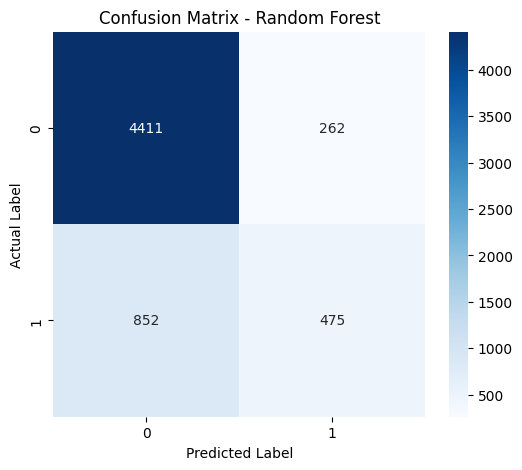

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC Score : 0.7566689689571365


In [10]:
#random forest classifier
model_rf= RandomForestClassifier(random_state=42)
model_rf.fit(X_train,y_train)

y_pred_rf=model_rf.predict(X_test)

accuracy_rf=accuracy_score(y_test,y_pred_rf)
print(f"Accuracy Percentage : {accuracy_rf*100:.2f}%")

precision_rf=precision_score(y_test,y_pred_rf)

recall_rf=recall_score(y_test,y_pred_rf)

f1_rf=f1_score(y_test,y_pred_rf)

print(f"Precision : {precision_rf:.2f}")
print(f"Recall    : {recall_rf:.2f}")
print(f"F1-Score  : {f1_rf:.2f}")

rf_matrix=confusion_matrix(y_test,y_pred_rf)
print("confusion matrix for Random Forest\n",rf_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(rf_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_rf))

y_prob_rf= model_rf.predict_proba( X_test)[:,1]
roc_rf= roc_auc_score(y_test,y_prob_rf)
print("ROC-AUC Score :", roc_rf)

In [11]:
'''
Observation:-
- Accuracy: 81.43%
- Precision: 0.64
- Recall: 0.36
- F1-Score: 0.46
- ROC-AUC: 0.7567
'''

'\nObservation:-\n- Accuracy: 81.43%\n- Precision: 0.64\n- Recall: 0.36\n- F1-Score: 0.46\n- ROC-AUC: 0.7567\n'

Accuracy Percentage : 79.50%
Precision : 0.56
Recall    : 0.34
F1-Score  : 0.43
confusion matrix for K-Nearest Neighbor 
 [[4313  360]
 [ 870  457]]


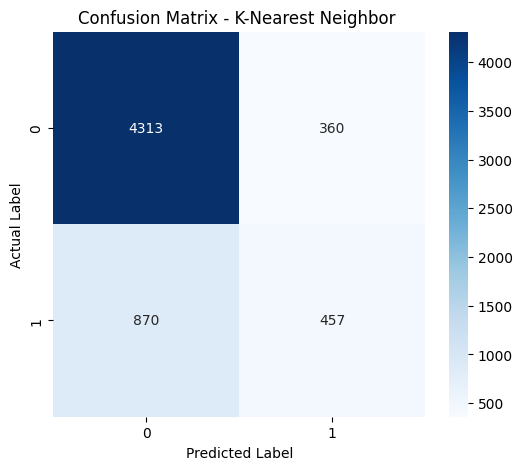

              precision    recall  f1-score   support

           0       0.83      0.92      0.88      4673
           1       0.56      0.34      0.43      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.63      0.65      6000
weighted avg       0.77      0.80      0.78      6000

ROC-AUC Score : 0.7032456973964658


In [12]:
#K-Nearest-Neighbor(KNN)
model_knn= KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled,y_train)

y_pred_knn=model_knn.predict(X_test_scaled)

accuracy_knn=accuracy_score(y_test,y_pred_knn)
print(f"Accuracy Percentage : {accuracy_knn*100:.2f}%")

precision_knn=precision_score(y_test,y_pred_knn)

recall_knn=recall_score(y_test,y_pred_knn)

f1_knn=f1_score(y_test,y_pred_knn)

print(f"Precision : {precision_knn:.2f}")
print(f"Recall    : {recall_knn:.2f}")
print(f"F1-Score  : {f1_knn:.2f}")

knn_matrix=confusion_matrix(y_test,y_pred_knn)
print("confusion matrix for K-Nearest Neighbor \n",knn_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(knn_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - K-Nearest Neighbor ")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_knn))

y_prob_knn= model_knn.predict_proba( X_test_scaled)[:,1]
roc_knn= roc_auc_score(y_test,y_prob_knn)
print("ROC-AUC Score :", roc_knn)

In [13]:
'''
Observation:-
- Accuracy: 79.50%
- Precision: 0.56
- Recall: 0.34
- F1-Score: 0.43
- ROC-AUC: 0.7032
'''

'\nObservation:-\n- Accuracy: 79.50%\n- Precision: 0.56\n- Recall: 0.34\n- F1-Score: 0.43\n- ROC-AUC: 0.7032\n'

Accuracy Percentage : 80.85%
Precision : 0.66
Recall    : 0.27
F1-Score  : 0.38
confusion matrix for SVM 
 [[4492  181]
 [ 968  359]]


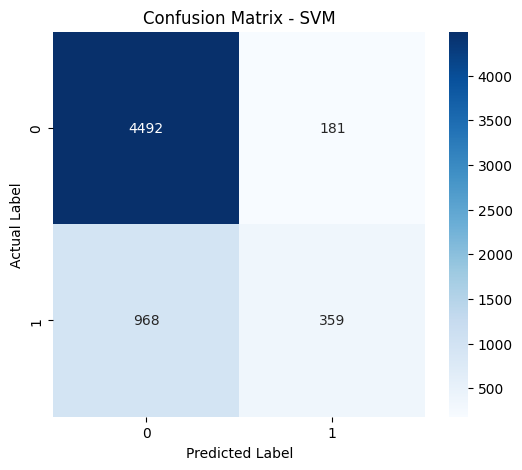

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.66      0.27      0.38      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000

ROC-AUC Score : 0.7119556444362595


In [27]:
#Support Vector Machine(SVM)
model_svm=SVC(kernel='linear',probability=True,random_state=42)
model_svm.fit(X_train_scaled,y_train)

y_pred_svm=model_svm.predict(X_test_scaled)

accuracy_svm=accuracy_score(y_test,y_pred_svm)
print(f"Accuracy Percentage : {accuracy_svm*100:.2f}%")

precision_svm=precision_score(y_test,y_pred_svm)

recall_svm=recall_score(y_test,y_pred_svm)

f1_svm=f1_score(y_test,y_pred_svm)

print(f"Precision : {precision_svm:.2f}")
print(f"Recall    : {recall_svm:.2f}")
print(f"F1-Score  : {f1_svm:.2f}")

svm_matrix=confusion_matrix(y_test,y_pred_svm)
print("confusion matrix for SVM \n",svm_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(svm_matrix,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(classification_report(y_test,y_pred_svm))

y_prob_svm= model_svm.predict_proba( X_test_scaled)[:,1]
roc_svm= roc_auc_score(y_test,y_prob_svm)
print("ROC-AUC Score :", roc_svm)

In [24]:
'''
Observation:-
- Accuracy: 80.85%
- Precision: 0.66
- Recall: 0.27
- F1-Score: 0.38
- ROC-AUC: 0.7119
'''

'\nObservation:-\n- Accuracy: 80.85%\n- Precision: 0.66\n- Recall: 0.27\n- F1-Score: 0.38\n- ROC-AUC: 0.7119\n'

In [25]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","KNN","SVM"],
    "Accuracy": [ accuracy_lr,accuracy_dt,accuracy_rf,accuracy_knn,accuracy_svm],
    "Precision": [precision_lr,precision_dt,precision_rf,precision_knn,precision_svm ],
    "Recall": [recall_lr,recall_dt,recall_rf,recall_knn,recall_svm],
    "F1-Score": [f1_lr,f1_dt,f1_rf,f1_knn,f1_svm ],
    "ROC-AUC": [roc_lr, roc_dt,roc_rf,roc_knn,roc_svm]
})
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.806,0.661,0.253,0.366,0.735
1,Decision Tree,0.720,0.377,0.411,0.393,0.610
2,Random Forest,0.814,0.645,0.358,0.460,0.757
3,KNN,0.795,0.559,0.344,0.426,0.703
4,SVM,0.808,0.665,0.271,0.385,0.712


In [17]:
comparison.style.highlight_max(subset=["Accuracy", "F1-Score", "ROC-AUC"],color="pink")

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.806167,0.661417,0.253203,0.366213,0.734562
1,Decision Tree,0.719500,0.376902,0.410701,0.393076,0.610403
2,Random Forest,0.814333,0.644505,0.357950,0.460271,0.756669
3,KNN,0.795000,0.559364,0.344386,0.426306,0.703246
4,SVM,0.808500,0.664815,0.270535,0.384574,0.711956


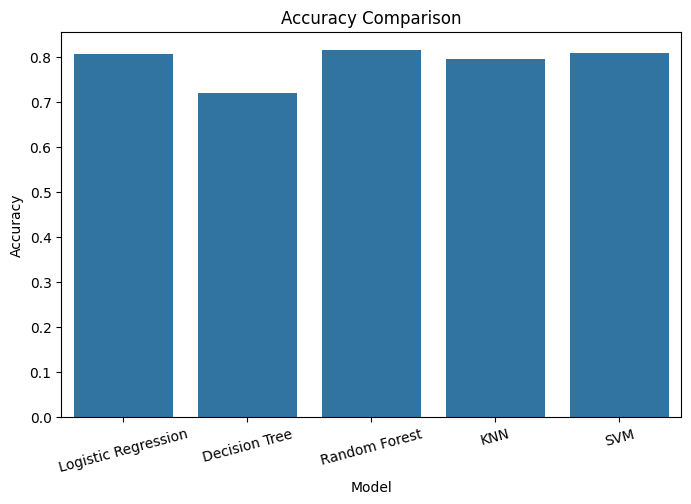

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)
plt.title("Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

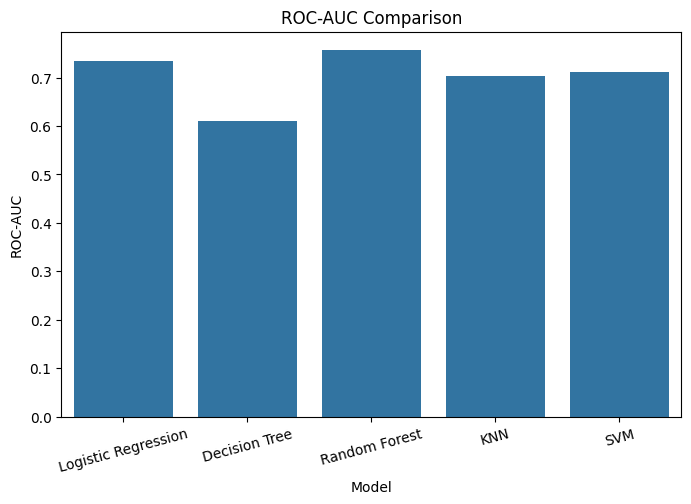

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="ROC-AUC",
    data=comparison
)
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)
plt.show()

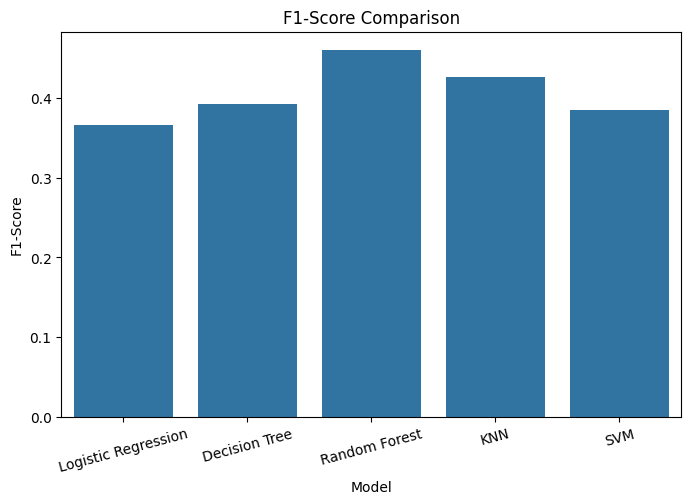

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="F1-Score",
    data=comparison
)
plt.title("F1-Score Comparison")
plt.xticks(rotation=15)
plt.show()

In [21]:
best_model = comparison.loc[comparison["Accuracy"].idxmax(), "Model"]

print(f"Selected Model: {best_model}")

Selected Model: Random Forest


In [37]:
import os

print(os.path.exists(r"E:\credit card default prediction"))
print(os.path.exists(r"E:\credit card default prediction\models"))

True
False


In [38]:

os.makedirs(r"E:\credit card default prediction\models", exist_ok=True)

In [36]:

import joblib

joblib.dump(
    model_rf,
    r"E:\credit card default prediction\models\random_forest_model.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\credit card default prediction\\models\\random_forest_model.pkl'

In [33]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [34]:
import os
print(os.getcwd())

C:\Users\user


In [35]:
os.listdir()


['.arduinoIDE',
 '.cache',
 '.codex',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.spss',
 '.spyder-py3',
 '.streamlit',
 '.virtual_documents',
 '.vscode',
 '.vscode-shared',
 '3D Objects',
 'ai termwork sem 1',
 'AI-ML codes 31-3-26.html',
 'AI-ML codes.ipynb',
 'Ai_ml lab codes.ipynb',
 'app.py',
 'AppData',
 'Application Data',
 'apriori.ipynb',
 'astar.ipynb',
 'care.csv',
 'Contacts',
 'Cookies',
 'credit scoring model training .ipynb',
 'credit scoring-eda and preprocessing.ipynb',
 'customer_data.csv',
 'datanormalization.ipynb',
 'dataset_reviews.csv',
 'dataset_reviews2.csv',
 'default of credit card clients.csv',
 'desicion tree.ipynb',
 'dfs bfs code.ipynb',
 'disease_risk.csv',
 'Documents',
 'Downloads',
 'Favorites',
 'feature selection and engineering.ipynb',
 'graph plots.ipynb',
 'health.csv',
 'healthcare.csv',
 'healthcare1.csv',
 'iCloudDrive',
 'iCloudPhotos',
 'IntelGraphicsProfiles',
 'jupyter-.url',
 'knn and kmea